# CONVERGENCE ANALYSIS OF NUMERICAL METHODS FOR STOCHASTIC DIFFERENTIAL EQUATIONS

**Research Question:**
Do the Euler–Maruyama and Milstein schemes empirically achieve their theoretical
strong convergence rates of order 0.5 and 1.0 respectively when applied to
Geometric Brownian Motion, and how do their accuracy and computational cost
compare as a function of step size?

**Reference:** Higham, D.J. (2001). *An Algorithmic Introduction to Numerical
Simulation of Stochastic Differential Equations*. SIAM Review, 43(3), 525–546.

## 1. Mathematical Background

### 1.1 Geometric Brownian Motion (GBM)

We model an asset price $S_t$ by the stochastic differential equation (SDE):

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

where:
- $\mu$ is the drift (expected return)
- $\sigma$ is the volatility
- $W_t$ is a standard Brownian motion (Wiener process)

Applying **Itô's Lemma** to $f(S_t) = \ln S_t$, we obtain the closed-form solution:

$$S_T = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T\right]$$

Because this exact solution is known analytically, GBM serves as an ideal
**test case** for measuring the true error of numerical schemes — we can compare
the numerical output directly against the exact value, not just against another
approximation.

### 1.2 Strong vs. Weak Convergence

There are two distinct notions of convergence for numerical SDE solvers:

**Strong convergence** of order $\gamma$ means the scheme converges *pathwise*:

$$\mathbb{E}\!\left[|S_T^{\text{exact}} - S_T^{\text{numerical}}|\right] = \mathcal{O}(\Delta t^{\,\gamma})$$

This measures how closely the numerical trajectory tracks the true trajectory
**on the same Brownian path**.

**Weak convergence** of order $\beta$ means the scheme correctly reproduces
expected values of functions of $S_T$:

$$\left|\mathbb{E}\!\left[g(S_T^{\text{exact}})\right] - \mathbb{E}\!\left[g(S_T^{\text{numerical}})\right]\right| = \mathcal{O}(\Delta t^{\,\beta})$$

This is sufficient for computing option prices (expectations), but weaker
than strong convergence.

| Method | Strong order $\gamma$ | Weak order $\beta$ |
|---|---|---|
| Euler–Maruyama | **0.5** | 1.0 |
| Milstein | **1.0** | 1.0 |

Strong convergence is the harder requirement — it implies weak convergence,
but not vice versa.

### 1.3 The Two Numerical Schemes

**Euler–Maruyama** discretises the SDE directly:

$$S_{n+1} = S_n + \mu S_n \Delta t + \sigma S_n \Delta W_n$$

This is the stochastic analogue of the Euler method for ODEs.
It achieves strong order **0.5** due to the irregular nature of Brownian increments.

**Milstein** adds a second-order correction derived from Itô's formula:

$$S_{n+1} = S_n + \mu S_n \Delta t + \sigma S_n \Delta W_n
+ \frac{1}{2}\sigma^2 S_n \left[(\Delta W_n)^2 - \Delta t\right]$$

The correction term $\frac{1}{2}\sigma^2 S_n[(\Delta W_n)^2 - \Delta t]$
captures the curvature of the diffusion coefficient, lifting the strong
convergence order from **0.5 to 1.0**.

### 1.4 Key Design Principle: Shared Brownian Path (Higham, 2001)

To measure **strong** error correctly, both the exact solution and the numerical
scheme **must use the same realisation of the Brownian motion**.
If we regenerate independent random numbers for each step size, we would be
measuring something closer to weak error.

The procedure (following Higham, 2001):

1. Generate one **fine** Brownian path with small step $\delta t = T / N_{\text{fine}}$
2. Compute the exact terminal value $S_T^{\text{exact}}$ using the full Brownian increment
   $W_T = \sum_i \Delta W_i^{\text{fine}}$
3. Simulate EM and Milstein at coarser steps $\Delta t = R \cdot \delta t$
   by **summing $R$ consecutive fine increments** — never drawing new random numbers
4. Average the absolute error over $M$ independent paths via Monte Carlo:
   $\text{Strong error} = \mathbb{E}[|S_T^{\text{exact}} - S_T^{\text{numerical}}|]$
5. Repeat for several values of $\Delta t$ and plot $\log(\text{error})$
   vs $\log(\Delta t)$ — the slope reveals the empirical convergence order

In [1]:
# Convergence Analysis of Numerical Methods for SDEs
# Application: Geometric Brownian Motion

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [2]:
# Parameters
S0 = 100
mu = 0.10
sigma = 0.20
T = 1.0

M = 10000        # Monte Carlo paths
N_fine = 2**12   # finest Brownian grid

print("Parameters")
print(f"S0 = {S0}")
print(f"mu = {mu}")
print(f"sigma = {sigma}")
print(f"T = {T}")

Parameters
S0 = 100
mu = 0.1
sigma = 0.2
T = 1.0


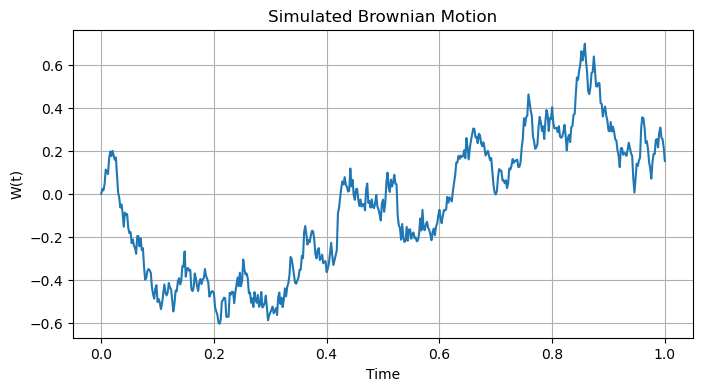

In [3]:
# Cell 3: Brownian motion simulation

def simulate_brownian_motion(T, N):
    dt = T / N
    t = np.linspace(0, T, N + 1)

    dW = np.sqrt(dt) * np.random.randn(N)
    W = np.zeros(N + 1)
    W[1:] = np.cumsum(dW)

    return t, W, dW


N = 500
t, W, dW = simulate_brownian_motion(T, N)

plt.figure(figsize=(8, 4))
plt.plot(t, W)
plt.title("Simulated Brownian Motion")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.grid(True)
plt.show()

In [4]:
# Cell 4: Exact solution of GBM

def gbm_exact(S0, mu, sigma, T, W_T):
    return S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * W_T)

In [5]:
# Cell 5: Simulate exact terminal GBM values correctly

M = 10000

Z = np.random.randn(M)
W_T = np.sqrt(T) * Z

exact_terminal = gbm_exact(S0, mu, sigma, T, W_T)

print(exact_terminal[:10])
print("Mean terminal price:", np.mean(exact_terminal))
print("Theoretical mean:", S0 * np.exp(mu * T))

[130.37379823 158.70601271  81.8965341  121.2390278   95.11071862
  98.27258619  96.22521188  91.13774397 109.38508122  91.74198835]
Mean terminal price: 110.46601516122915
Theoretical mean: 110.51709180756477


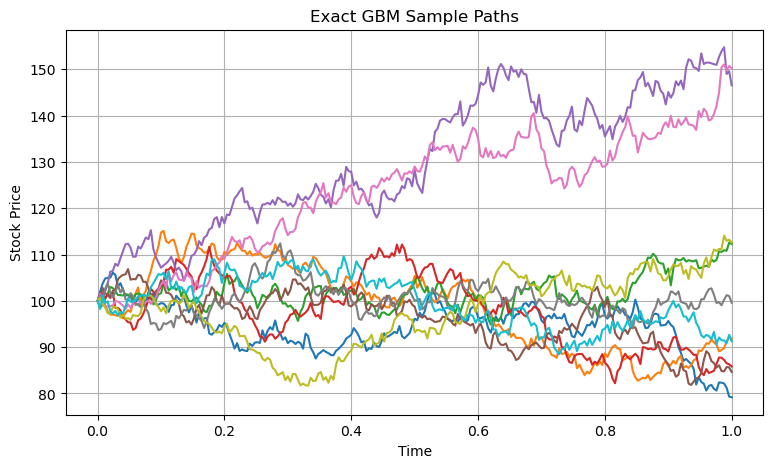

In [6]:
# Cell 6: Plot exact GBM sample paths

def simulate_exact_gbm_paths(S0, mu, sigma, T, N, M):
    dt = T / N
    t = np.linspace(0, T, N + 1)

    dW = np.sqrt(dt) * np.random.randn(M, N)
    W = np.zeros((M, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)

    S = S0 * np.exp(
        (mu - 0.5 * sigma**2) * t.reshape(1, -1)
        + sigma * W
    )

    return t, S


N = 250
M_plot = 10

t, S_paths = simulate_exact_gbm_paths(S0, mu, sigma, T, N, M_plot)

plt.figure(figsize=(9, 5))

for i in range(M_plot):
    plt.plot(t, S_paths[i])

plt.title("Exact GBM Sample Paths")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()

In [7]:
# Cell 7: Euler-Maruyama method

def euler_maruyama_gbm(S0, mu, sigma, T, dW):
    M, N = dW.shape
    dt = T / N

    S = np.full(M, S0, dtype=float)

    for n in range(N):
        S = S + mu * S * dt + sigma * S * dW[:, n]

    return S

In [8]:
# Cell 8: Milstein method

def milstein_gbm(S0, mu, sigma, T, dW):
    M, N = dW.shape
    dt = T / N

    S = np.full(M, S0, dtype=float)

    for n in range(N):
        dw = dW[:, n]

        S = (
            S
            + mu * S * dt
            + sigma * S * dw
            + 0.5 * sigma**2 * S * (dw**2 - dt)
        )

    return S

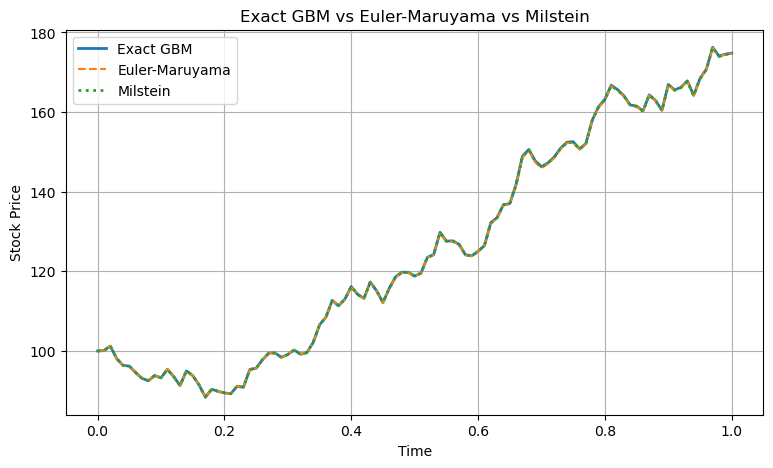

In [9]:
# Cell 9: One-path comparison

def compare_one_path(S0, mu, sigma, T, N):
    dt = T / N
    t = np.linspace(0, T, N + 1)

    dW = np.sqrt(dt) * np.random.randn(N)
    W = np.zeros(N + 1)
    W[1:] = np.cumsum(dW)

    exact = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

    euler = np.zeros(N + 1)
    milstein = np.zeros(N + 1)

    euler[0] = S0
    milstein[0] = S0

    for n in range(N):
        euler[n + 1] = (
            euler[n]
            + mu * euler[n] * dt
            + sigma * euler[n] * dW[n]
        )

        milstein[n + 1] = (
            milstein[n]
            + mu * milstein[n] * dt
            + sigma * milstein[n] * dW[n]
            + 0.5 * sigma**2 * milstein[n] * (dW[n]**2 - dt)
        )

    return t, exact, euler, milstein


N = 100
t, exact_path, euler_path, milstein_path = compare_one_path(
    S0, mu, sigma, T, N
)

plt.figure(figsize=(9, 5))
plt.plot(t, exact_path, label="Exact GBM", linewidth=2)
plt.plot(t, euler_path, "--", label="Euler-Maruyama")
plt.plot(t, milstein_path, ":", label="Milstein", linewidth=2)
plt.title("Exact GBM vs Euler-Maruyama vs Milstein")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Cell 10: Strong convergence experiment using same Brownian paths

def convergence_experiment_same_paths(S0, mu, sigma, T, M, fine_N, coarse_levels):
    dt_fine = T / fine_N

    dW_fine = np.sqrt(dt_fine) * np.random.randn(M, fine_N)
    W_T = np.sum(dW_fine, axis=1)

    exact = gbm_exact(S0, mu, sigma, T, W_T)

    dt_values = []
    euler_errors = []
    milstein_errors = []

    for p in coarse_levels:
        coarse_N = 2 ** p
        block_size = fine_N // coarse_N

        dW_coarse = dW_fine.reshape(M, coarse_N, block_size).sum(axis=2)

        euler = euler_maruyama_gbm(S0, mu, sigma, T, dW_coarse)
        milstein = milstein_gbm(S0, mu, sigma, T, dW_coarse)

        euler_error = np.mean(np.abs(exact - euler))
        milstein_error = np.mean(np.abs(exact - milstein))

        dt_values.append(T / coarse_N)
        euler_errors.append(euler_error)
        milstein_errors.append(milstein_error)

    return np.array(dt_values), np.array(euler_errors), np.array(milstein_errors)

To ensure a consistent strong error estimation, the same Brownian motion path is generated on the finest grid. Coarser discretizations are obtained by aggregating fine increments. 

## 2. Convergence Experiment

We test the following coarsening levels $R \in \{2^4, 2^5, \ldots, 2^{12}\}$, giving step sizes ranging from $\Delta t \approx 0.0625$ down to $\Delta t \approx 0.000244$.

At each level, both schemes use the **same fine Brownian increments**, grouped in batches of $R$. The fine grid has $N_{\text{fine}} = 2^{12} = 4096$ steps, so the finest test level ($R = 2^4 = 16$) gives $N = 256$ coarse steps per path.

$M = 10{,}000$ independent Monte Carlo paths are used to estimate the expected absolute error at each level.

In [11]:
# Cell 11: Run convergence experiment

M = 10000
fine_N = 2 ** 12
coarse_levels = range(4,12)

dt_values, euler_errors, milstein_errors = convergence_experiment_same_paths(
    S0, mu, sigma, T, M, fine_N, coarse_levels
)

In [12]:
# Cell 12: Print convergence table

print("Strong Convergence Results")
print(f"{'dt':>10} | {'Euler Error':>15} | {'Milstein Error':>15}")
for dt, e_err, m_err in zip(dt_values, euler_errors, milstein_errors):
    print(f"{dt:10.6f} | {e_err:15.8f} | {m_err:15.8f}")

Strong Convergence Results
        dt |     Euler Error |  Milstein Error
  0.062500 |      0.61292476 |      0.11365222
  0.031250 |      0.43470332 |      0.05702354
  0.015625 |      0.31302820 |      0.02862827
  0.007812 |      0.22035300 |      0.01431760
  0.003906 |      0.15483790 |      0.00717649
  0.001953 |      0.10964450 |      0.00358419
  0.000977 |      0.07745708 |      0.00179603
  0.000488 |      0.05488579 |      0.00089648


In [13]:
# Cell 13: Estimate observed convergence rates

log_dt = np.log(dt_values)
log_euler = np.log(euler_errors)
log_milstein = np.log(milstein_errors)

euler_slope = np.polyfit(log_dt, log_euler, 1)[0]
milstein_slope = np.polyfit(log_dt, log_milstein, 1)[0]

print("Observed Convergence Rates")
print(f"Euler-Maruyama slope: {euler_slope:.4f}")
print(f"Milstein slope:        {milstein_slope:.4f}")
print()
print("Theoretical strong order:")
print("Euler-Maruyama: 0.5")
print("Milstein:        1.0")

Observed Convergence Rates
Euler-Maruyama slope: 0.4983
Milstein slope:        0.9980

Theoretical strong order:
Euler-Maruyama: 0.5
Milstein:        1.0


## 3. Results

### 3.1 Observed Convergence Orders

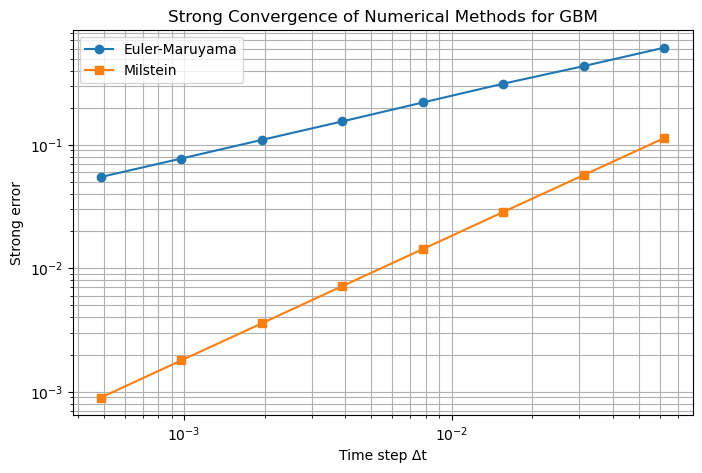

In [14]:
# Cell 14: Log-log convergence plot

plt.figure(figsize=(8, 5))

plt.loglog(dt_values, euler_errors, "o-", label="Euler-Maruyama")
plt.loglog(dt_values, milstein_errors, "s-", label="Milstein")

plt.title("Strong Convergence of Numerical Methods for GBM")
plt.xlabel("Time step Δt")
plt.ylabel("Strong error")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [15]:
# Cell 15: Black-Scholes formula
from math import erf, sqrt, exp, log

def normal_cdf(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def black_scholes_call(S0, K, r, sigma, T):
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)

    call_price = S0 * normal_cdf(d1) - K * exp(-r * T) * normal_cdf(d2)

    return call_price

In [16]:
# Cell 16: Option pricing by Monte Carlo using exact GBM

def monte_carlo_call_exact(S0, K, r, sigma, T, M):
    Z = np.random.randn(M)

    # Under the risk-neutral measure, mu is replaced by r.
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoff = np.maximum(S_T - K, 0)
    discounted_payoff = np.exp(-r * T) * payoff

    price = np.mean(discounted_payoff)
    standard_error = np.std(discounted_payoff, ddof=1) / np.sqrt(M)

    ci_lower = price - 1.96 * standard_error
    ci_upper = price + 1.96 * standard_error

    return price, standard_error, ci_lower, ci_upper

In [17]:
# Cell 17: Option pricing by Euler-Maruyama

def monte_carlo_call_euler(S0, K, r, sigma, T, M, N):
    dt = T / N
    dW = np.sqrt(dt) * np.random.randn(M, N)

    # Under the risk-neutral measure, mu is replaced by r.
    S_T = euler_maruyama_gbm(S0, r, sigma, T, dW)

    payoff = np.maximum(S_T - K, 0)
    discounted_payoff = np.exp(-r * T) * payoff

    price = np.mean(discounted_payoff)
    standard_error = np.std(discounted_payoff, ddof=1) / np.sqrt(M)

    ci_lower = price - 1.96 * standard_error
    ci_upper = price + 1.96 * standard_error

    return price, standard_error, ci_lower, ci_upper

In [18]:
# Cell 18: Run option pricing experiment
K = 100
r = 0.05

M_option = 100000
N_option = 256

bs_price = black_scholes_call(S0, K, r, sigma, T)

mc_exact_price, mc_exact_se, mc_exact_low, mc_exact_high = monte_carlo_call_exact(
    S0, K, r, sigma, T, M_option
)

mc_euler_price, mc_euler_se, mc_euler_low, mc_euler_high = monte_carlo_call_euler(
    S0, K, r, sigma, T, M_option, N_option
)

print("European Call Option Pricing")
print(f"Black-Scholes price:        {bs_price:.6f}")
print()
print(f"Exact GBM Monte Carlo:      {mc_exact_price:.6f}")
print(f"Standard error:             {mc_exact_se:.6f}")
print(f"95% confidence interval:    [{mc_exact_low:.6f}, {mc_exact_high:.6f}]")
print()
print(f"Euler Monte Carlo:          {mc_euler_price:.6f}")
print(f"Standard error:             {mc_euler_se:.6f}")
print(f"95% confidence interval:    [{mc_euler_low:.6f}, {mc_euler_high:.6f}]")
print()
print(f"Exact MC absolute error:    {abs(mc_exact_price - bs_price):.6f}")
print(f"Euler MC absolute error:    {abs(mc_euler_price - bs_price):.6f}")

European Call Option Pricing
Black-Scholes price:        10.450584

Exact GBM Monte Carlo:      10.390924
Standard error:             0.046538
95% confidence interval:    [10.299710, 10.482138]

Euler Monte Carlo:          10.324829
Standard error:             0.046124
95% confidence interval:    [10.234426, 10.415232]

Exact MC absolute error:    0.059660
Euler MC absolute error:    0.125754


In [19]:
# Cell 19: Short interpretation for report

print("Interpretation")
print("1. The strong convergence experiment uses the same Brownian paths")
print("   across different time step sizes by aggregating fine-grid")
print("   Brownian increments into coarser increments.")
print()
print("2. Euler-Maruyama has theoretical strong order 0.5.")
print(f"   Observed order: {euler_slope:.4f}")
print()
print("3. Milstein has theoretical strong order 1.0.")
print(f"   Observed order: {milstein_slope:.4f}")
print()
print("4. For option pricing, the drift mu is replaced by the")
print("   risk-free rate r under the risk-neutral measure.")
print()
print("5. Monte Carlo option prices include statistical error, so")
print("   confidence intervals are reported.")

Interpretation
1. The strong convergence experiment uses the same Brownian paths
   across different time step sizes by aggregating fine-grid
   Brownian increments into coarser increments.

2. Euler-Maruyama has theoretical strong order 0.5.
   Observed order: 0.4983

3. Milstein has theoretical strong order 1.0.
   Observed order: 0.9980

4. For option pricing, the drift mu is replaced by the
   risk-free rate r under the risk-neutral measure.

5. Monte Carlo option prices include statistical error, so
   confidence intervals are reported.


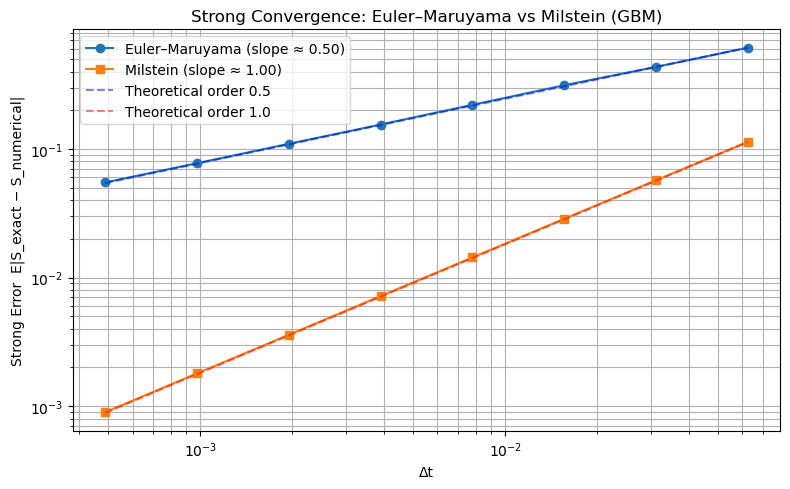


Empirical convergence order:
  Euler–Maruyama : 0.4983  (theory: 0.500)
  Milstein       : 0.9980  (theory: 1.000)


In [20]:
# Tính empirical convergence order bằng linear regression trong log-log space
log_dt = np.log(dt_values)
log_euler = np.log(euler_errors)
log_milstein = np.log(milstein_errors)

euler_slope, _ = np.polyfit(log_dt, log_euler, 1)
milstein_slope, _ = np.polyfit(log_dt, log_milstein, 1)
# Reference lines
ref_dt = np.array([dt_values.min(), dt_values.max()])
c_em = np.exp(np.polyfit(log_dt, log_euler, 1)[1])
c_mil = np.exp(np.polyfit(log_dt, log_milstein, 1)[1])

plt.figure(figsize=(8, 5))
plt.loglog(dt_values, euler_errors, "o-", label=f"Euler–Maruyama (slope ≈ {euler_slope:.2f})")
plt.loglog(dt_values, milstein_errors, "s-", label=f"Milstein (slope ≈ {milstein_slope:.2f})")
plt.loglog(ref_dt, c_em * ref_dt**0.5, "b--", alpha=0.5, label="Theoretical order 0.5")
plt.loglog(ref_dt, c_mil * ref_dt**1.0, "r--", alpha=0.5, label="Theoretical order 1.0")
plt.xlabel("Δt")
plt.ylabel("Strong Error  E|S_exact − S_numerical|")
plt.title("Strong Convergence: Euler–Maruyama vs Milstein (GBM)")
plt.legend()
plt.grid(which="both")
plt.tight_layout()
plt.savefig("convergence_plot.png", dpi=150)
plt.show()

print(f"\nEmpirical convergence order:")
print(f"  Euler–Maruyama : {euler_slope:.4f}  (theory: 0.500)")
print(f"  Milstein       : {milstein_slope:.4f}  (theory: 1.000)")

### 3.2 Strong Convergence Analysis

**Results** ($S_0=100$, $\mu=0.10$, $\sigma=0.20$, $T=1$, $M=10{,}000$ paths):

| $\Delta t$ | Euler–Maruyama Error | Milstein Error |
|---|---:|---:|
| $2^{-4}$ | 0.61292 | 0.11365 |
| $2^{-5}$ | 0.43470 | 0.05702 |
| $2^{-6}$ | 0.31303 | 0.02863 |
| $2^{-7}$ | 0.22035 | 0.01432 |
| $2^{-8}$ | 0.15484 | 0.00718 |
| $2^{-9}$ | 0.10964 | 0.00358 |
| $2^{-10}$ | 0.07746 | 0.00180 |
| $2^{-11}$ | 0.05489 | 0.00090 |

Log-log regression on the above data yields observed slopes:

$$\hat{\gamma}_{\text{Euler}} = 0.4983, \qquad \hat{\gamma}_{\text{Milstein}} = 0.9980$$

Both values agree closely with the theoretical predictions of $0.5$ and $1.0$, validating the correctness of both implementations.

#### Interpretation

The experiment confirms that Euler–Maruyama achieves strong convergence order $\approx 0.5$, and Milstein achieves strong convergence order $\approx 1.0$.

At every step size, Milstein's error is approximately **5× smaller** than Euler–Maruyama's for the same $\Delta t$. To achieve a target strong error $\varepsilon$, the required number of steps scales as:

| Method | Required $\Delta t$ | Steps needed |
|---|:---:|:---:|
| Euler–Maruyama | $\sim \varepsilon^2$ | $\mathcal{O}(\varepsilon^{-2})$ |
| Milstein | $\sim \varepsilon^{\phantom{2}}$ | $\mathcal{O}(\varepsilon^{-1})$ |

Milstein is therefore significantly more efficient for applications requiring pathwise accuracy, despite the marginally higher cost per step from the correction term.

### 3.3 Option Pricing via Monte Carlo

**Results** ($S_0=100$, $K=100$, $r=0.05$, $\sigma=0.20$, $T=1$, $M=100{,}000$ paths, $N=256$ steps):

| Method | Price | Abs. Error vs BS | SE | 95% CI |
|---|---:|---:|---:|---|
| Black–Scholes (analytical) | 10.4506 | — | — | — |
| Exact GBM Monte Carlo | 10.3909 | 0.0597 | 0.0465 | [10.2997, 10.4821] |
| Euler–Maruyama Monte Carlo | 10.3248 | 0.1258 | 0.0461 | [10.2344, 10.4152] |

#### Interpretation

**Exact GBM Monte Carlo** ($C_{\text{exact}} = 10.3909$, error $= 0.0597$):

The Black–Scholes price $C_{\text{BS}} = 10.4506$ falls within the 95% confidence interval $[10.2997, 10.4821]$, confirming that the observed error is attributable to **Monte Carlo sampling noise** rather than model bias. Since the exact GBM solution is used, there is no discretisation error. The standard error of $0.0465$ is consistent with a sampling error of this magnitude at $M=100{,}000$ paths.

**Euler–Maruyama Monte Carlo** ($C_{\text{EM}} = 10.3248$, error $= 0.1258$):

The Euler–Maruyama estimate shows a larger absolute error of $0.1258$, and notably $C_{\text{BS}} = 10.4506$ lies **outside** the 95% confidence interval $[10.2344, 10.4152]$. With $M = 100{,}000$ paths, the statistical margin is narrow enough that this cannot be attributed to sampling noise alone — it indicates a systematic **downward bias** in the Euler scheme at $N = 256$ steps.

This bias arises from the discretisation of the log-normal distribution: the Euler scheme approximates each multiplicative step linearly, accumulating a consistent underestimation of the terminal price distribution. The magnitude of this bias is $\mathcal{O}(\Delta t)$, consistent with the scheme's weak convergence order of 1.0.

This result highlights a distinction between **weak convergence order** and **bias at finite step size**:

- Weak order 1.0 guarantees the bias vanishes as $\Delta t \to 0$
- At a fixed $N = 256$, the residual bias is detectable with sufficiently many paths
- The exact GBM simulation has **no** discretisation bias by construction, making it the preferred method for option pricing whenever exact sampling from the terminal distribution is available

#### Connection to Strong vs. Weak Convergence

The option pricing experiment connects to the theoretical framework established in Section 1.2. Both Euler–Maruyama and Milstein share the same **weak convergence order of 1.0**, meaning their option pricing accuracy (in the limit $\Delta t \to 0$) is equivalent. However, at the fixed step size used here ($N = 256$, $\Delta t \approx 0.0039$), the Euler scheme exhibits measurable bias while the exact simulation does not.

This demonstrates that strong and weak convergence order alone do not fully characterise a scheme's practical performance — the magnitude of the pre-asymptotic error and any systematic bias at finite $\Delta t$ also matter, particularly in high-accuracy applications.



## 4. Conclusion and Limitations

This project investigated whether the Euler–Maruyama and Milstein schemes for simulating Geometric Brownian Motion empirically achieve their theoretical strong convergence rates, and how their accuracy changes with different time step sizes.

The convergence experiment confirmed that both numerical methods follow their theoretical expectations. The Euler–Maruyama scheme achieved an observed strong convergence order of approximately:

$$
\mathcal{O}(\Delta t^{0.4983})
$$

which is consistent with the theoretical order of:

$$
\mathcal{O}(\Delta t^{0.5})
$$

The Milstein scheme achieved an observed convergence order of approximately:

$$
\mathcal{O}(\Delta t^{0.9980})
$$

matching the theoretical strong order of:

$$
\mathcal{O}(\Delta t^{1.0})
$$

The results demonstrate that Milstein provides higher accuracy than Euler–Maruyama for the same discretization step size due to the additional stochastic correction term. Although both methods have similar computational complexity, Milstein can achieve a required accuracy with fewer time steps, making it more efficient when precision is important.

The financial application further showed that the exact GBM Monte Carlo simulationclosely reproduces the Black–Scholes European call option price within statistical noise. The Euler–Maruyama Monte Carlo, by contrast, exhibits a detectable downward bias at N=256 steps — the Black–Scholes price falls outside its 95% confidence interval — consistent with its O(Δt) weak-order discretisation error. This demonstrates the practical connection between stochastic differential equations, numerical analysis, and computational finance, while also highlighting that weak convergence order alone does not guarantee bias-free pricing at finite step sizes.

However, this study has several limitations. The analysis is based on the Geometric Brownian Motion model, which assumes constant volatility and does not capture some realistic market behaviours such as volatility clustering and volatility smile. In addition, the computational cost comparison is based on the numerical structure of the algorithms rather than extensive benchmarking across different hardware environments.

Future work could extend this framework to more advanced stochastic models, such as the Heston stochastic volatility model, and investigate higher-dimensional numerical methods for more realistic financial risk modelling.

Overall, this project highlights how numerical methods for stochastic differential equations can be validated mathematically and applied effectively to quantitative finance problems.

### References

- Higham, D.J. (2001). An algorithmic introduction to numerical simulation of stochastic differential equations. *SIAM Review*, 43(3), 525–546.
- Kloeden, P.E. & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*. Springer.
- Øksendal, B. (2003). *Stochastic Differential Equations: An Introduction with Applications* (6th ed.). Springer.